In [1]:
import pyvista as pv

pv.set_jupyter_backend("static")



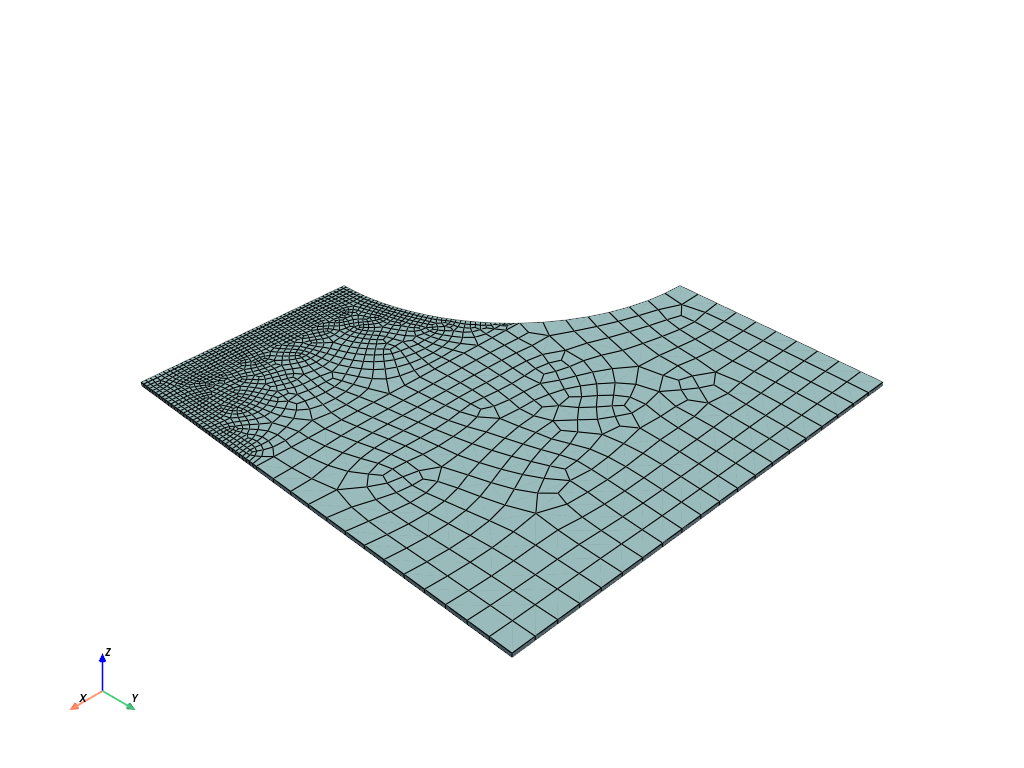

In [2]:
from torchfem.examples import get_example_file
import pyvista as pv

mesh = pv.read(get_example_file("quarter_plate_hole_3d.vtu"))
mesh.plot(show_edges=True)


# Isotropic damage in a quarter plate 
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/meyer-nils/torch-fem/blob/main/examples/basic/solid/plate_damage.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/meyer-nils/torch-fem/main?labpath=examples/basic/solid/plate_damage.ipynb)

Credits to Wiliams Ye!


In [55]:
import torch

from torchfem.data import get_data
from torchfem.io import import_mesh
from torchfem.materials import IsotropicDamage3D

import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)

In [95]:
import pyvista as pv
pv.set_jupyter_backend("static")

import pyvista as pv
from pyvistaqt import BackgroundPlotter  # پنجره‌ی Qt برای چرخاندن




## Material 

The material is elastic up to an equivalent strain (max. principal strain) of $\varepsilon_0$=0.0002. From there on, the damage evolution is computed with a strain softening exponential law. The fracture energy per unit area is 
$$
G_\textrm{f} = l_\textrm{c} \int_{\varepsilon_0}^{\infty} \sigma d \varepsilon = 0.048
$$
with the characteristic element length $l_c$.

In [98]:
# Elastic parameters (Young's modulus and Poisson's ratio)
E = 6000.0
nu = 0.3

# Damage parameters (Damage initiation strain and fracture energy)
eps_0 = 2.0e-4
G_f = 0.048


def d(kappa, cl):
    # Damage evolution law for exponential strain softening
    eps_f = G_f / (E * eps_0 * cl) + eps_0 / 2.0
    evolution = 1.0 - eps_0 / kappa * torch.exp(-(kappa - eps_0) / (eps_f - eps_0))
    evolution[kappa < eps_0] = 0.0

    return evolution


def d_prime(kappa, cl):
    # Derivative of the damage evolution law
    eps_f = G_f / (E * eps_0 * cl) + eps_0 / 2.0
    derivative = (
        eps_0
        * torch.exp(-(kappa - eps_0) / (eps_f - eps_0))
        * (1 / kappa**2 + 1 / (kappa * (eps_f - eps_0)))
    )
    derivative[kappa < eps_0] = 0.0

    return derivative


# Elastic properties
material = IsotropicDamage3D(E, nu, d, d_prime, "rankine")

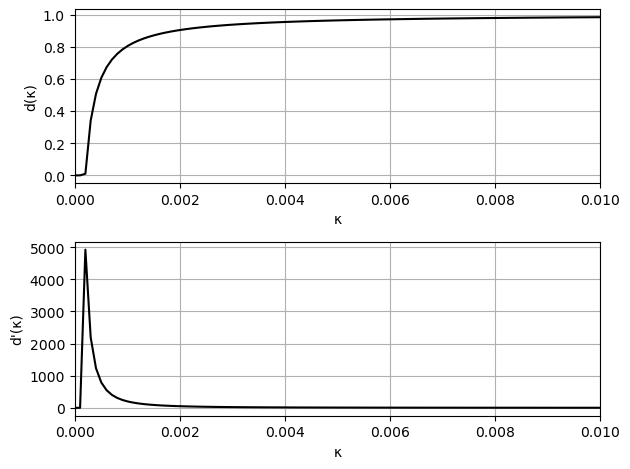

In [100]:
kappa_test = torch.linspace(0.0, 0.01, 100)

fig, ax = plt.subplots(2, 1)
ax[0].plot(kappa_test, d(kappa_test, 1.0), "-k")
ax[0].set_xlim(0.0, 0.01)
ax[0].set_xlabel("κ")
ax[0].set_ylabel("d(κ)")
ax[0].grid()
ax[1].plot(kappa_test, d_prime(kappa_test, 1.0), "-k")
ax[1].set_xlim(0.0, 0.01)
ax[1].set_xlabel("κ")
ax[1].set_ylabel("d'(κ)")
ax[1].grid()
plt.tight_layout()
plt.show()

## Quarter Plate Model

The solid model is imported from the example files. It is loaded in the 1-direction with a displacement boundary condition, the other boundaries are either symmetry conditions or free. 

In [103]:
model = import_mesh(get_data("quarter_plate_hole_3d.vtu"), material)

# Regions
left = model.nodes[:, 0] <= 0.1
bottom = model.nodes[:, 1] <= 0.1
top = model.nodes[:, 1] >= 99.9
back = model.nodes[:, 2] <= 0.1

# Boundary conditions
model.constraints[left, 0] = True
model.constraints[bottom, 1] = True
model.constraints[back, 2] = True
model.constraints[top, 1] = True
model.displacements[top, 1] = 0.05

# Increments
increments = torch.linspace(0.0, 1.0, 50)

# Visualize quarter plate
model.plot()

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

## Solve

This may take up to 2 minutes.

In [106]:
u, f, σ, F, α = model.solve(increments=increments, return_intermediate=True)

# Compute infinitesimal strain
H = F - torch.eye(3)
ε = 0.5 * (H.transpose(-1, -2) + H)

In [108]:
import numpy as np
import pyvista as pv
from torchfem.examples import get_example_file

# 1) مش اصلی quarter plate را از فایل می‌خوانیم
mesh = pv.read(get_example_file("quarter_plate_hole_3d.vtu"))

# 2) damage در آخرین اینکریمنت را از α می‌گیریم
#   فرض می‌کنیم ستون index=1 همان damage است (مثل قبلی که خودت داشتی)
damage_last = α[-1, :, 1].detach().cpu().numpy()   # shape: (n_elements,)

# damage را به‌عنوان cell_data روی مش ذخیره می‌کنیم
mesh.cell_data["Damage"] = damage_last

# 3) جابجایی‌ها در آخرین اینکریمنت
u_last = u[-1].detach().cpu().numpy()   # shape: (n_nodes, 3)

# یک کپی از مش می‌گیریم و مختصات را با u_last جمع می‌کنیم
deformed = mesh.copy()
coords = deformed.points.copy()         # (n_nodes, 3)

coords[:, 0] += u_last[:, 0]
coords[:, 1] += u_last[:, 1]
coords[:, 2] += u_last[:, 2]

deformed.points = coords


In [127]:
# پنجره‌ی تعاملی PyVistaQt
plotter = BackgroundPlotter()

plotter.add_mesh(
    deformed,
    scalars="Damage",   # از cell_data["Damage"] استفاده می‌کند
    cmap="Blues",
    show_edges=True,
)

plotter.add_axes()
plotter.show()          # یک پنجره‌ی جدا باز می‌شود که قابل چرخش است


## Results 

In this case, the damage initiates at the highest stress concentration at the hole and then propagates transverse to the load direction throughout the part. 

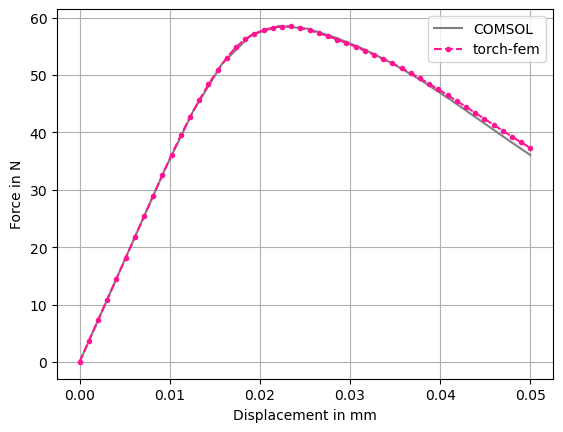

In [113]:
# Reference solution from COMSOL (obtained at higher resolution)
reference = torch.tensor(
    [
        [0.000e00, 0.000e00],
        [3.164e-03, 1.123e01],
        [6.329e-03, 2.246e01],
        [9.493e-03, 3.366e01],
        [1.265e-02, 4.389e01],
        [1.582e-02, 5.200e01],
        [1.898e-02, 5.696e01],
        [2.215e-02, 5.857e01],
        [2.531e-02, 5.808e01],
        [2.848e-02, 5.649e01],
        [3.164e-02, 5.444e01],
        [3.481e-02, 5.193e01],
        [3.797e-02, 4.899e01],
        [4.113e-02, 4.570e01],
        [4.430e-02, 4.223e01],
        [4.746e-02, 3.875e01],
        [4.999e-02, 3.605e01],
    ]
)

plt.plot(reference[:, 0], reference[:, 1], "-", label="COMSOL", color="gray")
plt.plot(
    u[:, top, 1].mean(dim=-1),
    f[:, top, 1].sum(dim=-1),
    ".--",
    label="torch-fem",
    color="deeppink",
)
plt.xlabel("Displacement in mm")
plt.ylabel("Force in N")
plt.grid()
plt.legend()
plt.show()

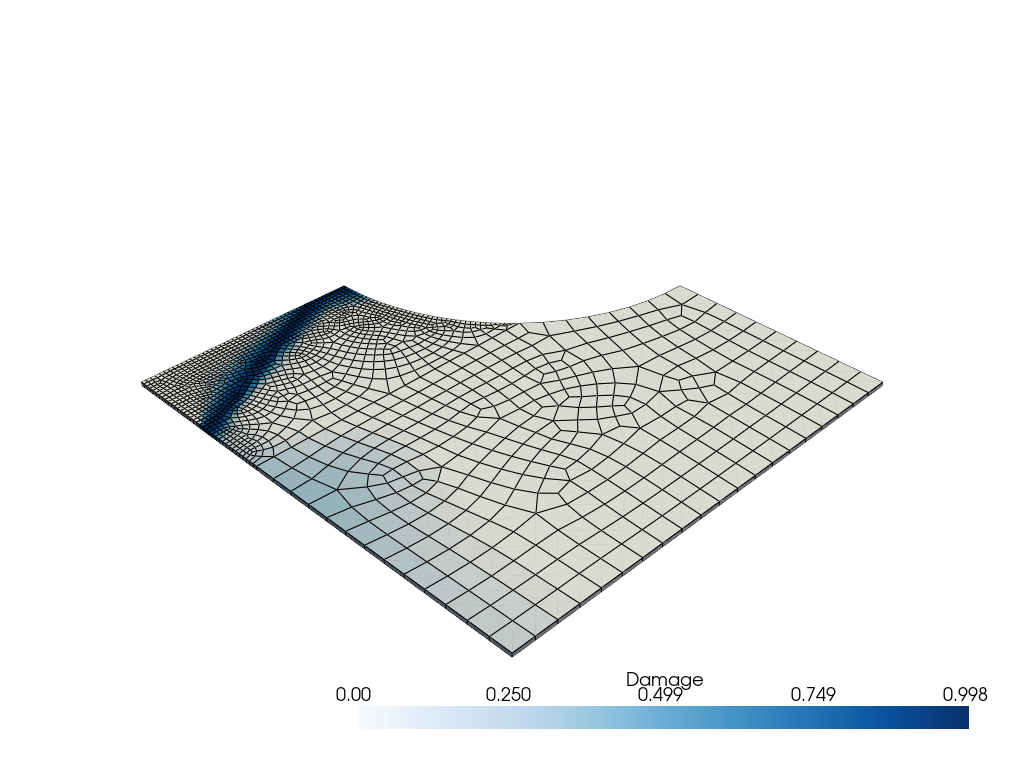

In [117]:
import torch
import pyvista as pv
from torchfem.examples import get_example_file

# ---- 1) مش quarter plate را دوباره از فایل vtu می‌خوانیم
mesh = pv.read(get_example_file("quarter_plate_hole_3d.vtu"))

# ---- 2) damage آخرین اینکریمنت را از alpha می‌گیریم
# alpha.shape = (n_increments, n_elements, 2)  --> ستون 1 = damage
damage_last = α[-1, :, 1].detach().cpu().numpy()  # (n_elements,)

# فرض می‌کنیم تعداد المان‌های مش با طول damage_last یکی است
mesh.cell_data["Damage"] = damage_last

# ---- 3) مش تغییرشکل‌یافته (با u[-1]) را می‌سازیم
u_last = u[-1].detach().cpu().numpy()  # (n_nodes, 3)

deformed = mesh.copy()
coords = deformed.points.copy()
coords[:, 0] += u_last[:, 0]
coords[:, 1] += u_last[:, 1]
coords[:, 2] += u_last[:, 2]
deformed.points = coords

# ---- 4) رسم: quarter plate تغییر شکل یافته با رنگِ Damage
pv.set_jupyter_backend("static")   # نمایش داخل نوت‌بوک

plotter = pv.Plotter()
plotter.add_mesh(
    deformed,
    scalars="Damage",   # اسم cell_data که بالا گذاشتیم
    cmap="Blues",
    show_edges=True,
)
plotter.show()


In [119]:
import pyvista as pv
from pyvistaqt import BackgroundPlotter  # پنجره‌ی Qt برای چرخاندن


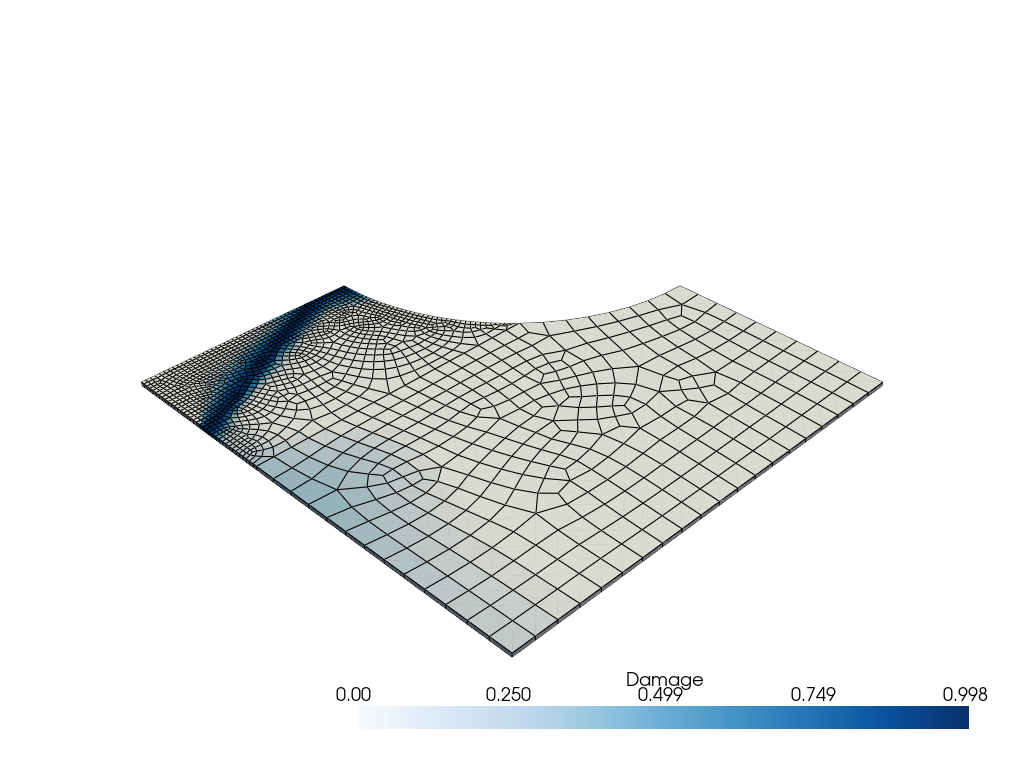

In [123]:
import pyvista as pv
pv.set_jupyter_backend("html")


plotter.show()


In [131]:
# پنجره‌ی تعاملی PyVistaQt
plotter = BackgroundPlotter()

plotter.add_mesh(
    deformed,
    scalars="Damage",   # از cell_data["Damage"] استفاده می‌کند
    cmap="Blues",
    show_edges=True,
)

plotter.add_axes()
plotter.show() 